# Load data

In [50]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

All imports successful!
PyTorch version: 2.11.0


In [51]:
data = scipy.io.loadmat('Xtrain.mat')
print(data)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Apr 29 11:11:31 2019', '__version__': '1.0', '__globals__': [], 'Xtrain': array([[ 86],
       [141],
       [ 95],
       [ 41],
       [ 22],
       [ 21],
       [ 32],
       [ 72],
       [138],
       [111],
       [ 48],
       [ 23],
       [ 19],
       [ 27],
       [ 59],
       [129],
       [129],
       [ 58],
       [ 27],
       [ 19],
       [ 24],
       [ 46],
       [112],
       [144],
       [ 73],
       [ 30],
       [ 20],
       [ 19],
       [ 37],
       [ 92],
       [152],
       [ 93],
       [ 36],
       [ 20],
       [ 18],
       [ 29],
       [ 71],
       [146],
       [117],
       [ 46],
       [ 23],
       [ 18],
       [ 22],
       [ 52],
       [128],
       [142],
       [ 62],
       [ 26],
       [ 17],
       [ 19],
       [ 37],
       [100],
       [158],
       [ 86],
       [ 32],
       [ 17],
       [ 17],
       [ 27],
       [ 72],
       [154],
       [118],

In [52]:
X = data['Xtrain']
print("Shape:", X.shape)
print("Data type:", X.dtype)
print("First 5 values:", X[:5])

Shape: (1000, 1)
Data type: uint8
First 5 values: [[ 86]
 [141]
 [ 95]
 [ 41]
 [ 22]]


# Data exploration

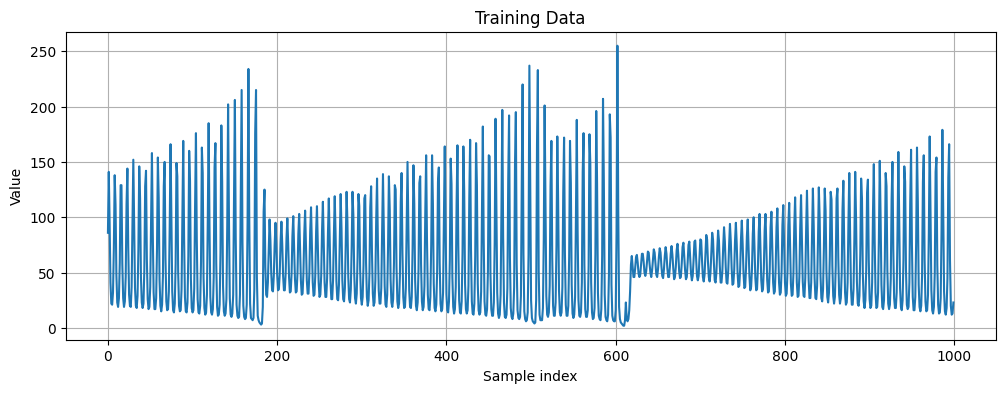

In [53]:
X = X.flatten()

plt.figure(figsize=(12, 4))
plt.plot(X)
plt.title("Training Data")
plt.xlabel("Sample index")
plt.ylabel("Value")
plt.grid(True)
plt.show()

## Data Exploration

The training data consists of 1000 samples with integer values between 0 and 255 (uint8).

Observations from the plot:
- The data shows a clear (zigzag) pattern
- The amplitude of the pattern varies: it starts small, grows larger, then resets
- This cycle repeats roughly 3 times across the 1000 samples


# Split data and normalize

In [54]:
N = len(X)
train_end = int(0.80 * N)

train_data = X[:train_end]
val_data = X[train_end:]

mu = train_data.mean()
sigma = train_data.std()

train_data = (train_data - mu) / sigma
val_data = (val_data - mu) / sigma

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Train mean:", train_data.mean())
print("Train std:", train_data.std())
print("First 5 validation values:", val_data[:5])

Train size: 800
Validation size: 200
Train mean: 1.9984014443252817e-17
Train std: 1.0
First 5 validation values: [-0.39128264 -0.64443761 -0.60224512 -0.18032017  0.70572221]


# Create sliding windows

In [55]:
def create_windows(data, p):
    X, y = [], []
    for i in range(len(data) - p):
        X.append(data[i:i+p])
        y.append(data[i+p])
    return np.array(X), np.array(y)

In [56]:
p = 5

X_train, y_train = create_windows(train_data, p)
val_with_context = np.concatenate([train_data[-p:], val_data])
X_val, y_val = create_windows(val_with_context, p)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("First training window:", X_train[0])
print("First training target:", y_train[0])

X_train shape: (795, 5)
y_train shape: (795,)
X_val shape: (200, 5)
y_val shape: (200,)
First training window: [ 0.55804848  1.71834207  0.7479147  -0.39128264 -0.79211134]
First training target: -0.813207587617998


In [57]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

print("Reshaped X_train:", X_train.shape)
print("Reshaped X_val:", X_val.shape)

Reshaped X_train: (795, 5, 1)
Reshaped X_val: (200, 5, 1)


# Convert to PyTorch tensors

In [58]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_val tensor shape:", X_val_tensor.shape)
print("y_val tensor shape:", y_val_tensor.shape)

X_train tensor shape: torch.Size([795, 5, 1])
y_train tensor shape: torch.Size([795])
X_val tensor shape: torch.Size([200, 5, 1])
y_val tensor shape: torch.Size([200])


# CNN model

In [59]:
class CNN(nn.Module):
    def __init__(self, p):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * p, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.dropout(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze()

model = CNN(p)
print(model)

CNN(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=80, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


# DataLoaders

In [60]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))

Number of training batches: 25
Number of validation batches: 7


# Train

In [61]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 200
train_losses, val_losses = [], []

for epoch in range(n_epochs):
    model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            val_batch_losses.append(criterion(model(X_batch), y_batch).item())
    val_losses.append(np.mean(val_batch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  train={train_losses[-1]:.6f}  val={val_losses[-1]:.6f}")

Epoch 50/200  train=0.055479  val=0.008754
Epoch 100/200  train=0.047218  val=0.006422
Epoch 150/200  train=0.034680  val=0.003338
Epoch 200/200  train=0.025944  val=0.006106


# Loss curves

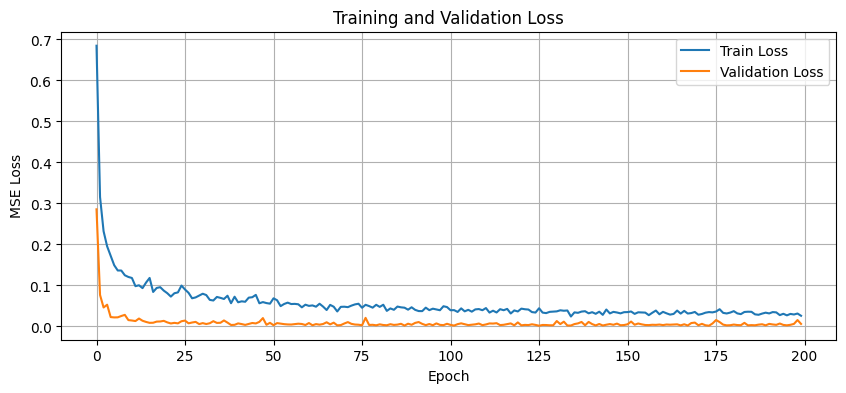

In [62]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Tune p

In [63]:
p_values = [5, 10, 15, 20, 25, 30, 35, 40]
p_val_mse = []

for p_cand in p_values:
    X_tr, y_tr = create_windows(train_data, p_cand)
    val_with_context = np.concatenate([train_data[-p_cand:], val_data])
    X_v, y_v = create_windows(val_with_context, p_cand)

    X_tr = X_tr.reshape((X_tr.shape[0], X_tr.shape[1], 1))
    X_v = X_v.reshape((X_v.shape[0], X_v.shape[1], 1))

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_v_t = torch.tensor(X_v, dtype=torch.float32)
    y_v_t = torch.tensor(y_v, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

    torch.manual_seed(42)
    m = CNN(p_cand)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    for _ in range(200):
        m.train()
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(m(xb), yb).backward()
            opt.step()

    m.eval()
    with torch.no_grad():
        val_mse = loss_fn(m(X_v_t), y_v_t).item()
    p_val_mse.append(val_mse)
    print(f"p={p_cand:2d}  val MSE={val_mse:.6f}")

best_p = p_values[np.argmin(p_val_mse)]
print(f"\nBest p: {best_p}")

p= 5  val MSE=0.004785
p=10  val MSE=0.007140
p=15  val MSE=0.002094
p=20  val MSE=0.001925
p=25  val MSE=0.007201
p=30  val MSE=0.001862
p=35  val MSE=0.001603
p=40  val MSE=0.003615

Best p: 35


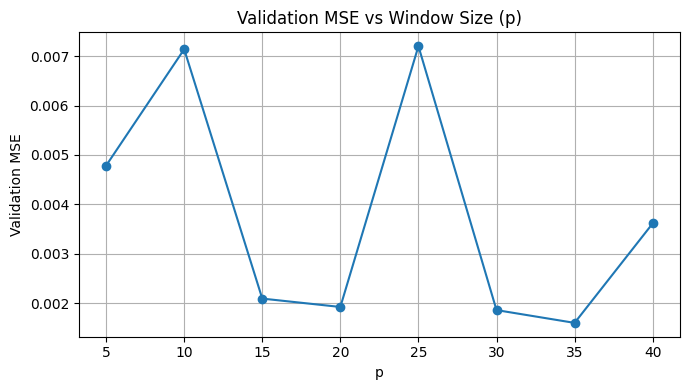

In [64]:
plt.figure(figsize=(7, 4))
plt.plot(p_values, p_val_mse, marker="o")
plt.xlabel("p")
plt.ylabel("Validation MSE")
plt.title("Validation MSE vs Window Size (p)")
plt.tight_layout()
plt.grid(True)
plt.show()

# Retrain with best p

Epoch 50/200  train=0.036640
Epoch 100/200  train=0.012556
Epoch 150/200  train=0.008463
Epoch 200/200  train=0.008702


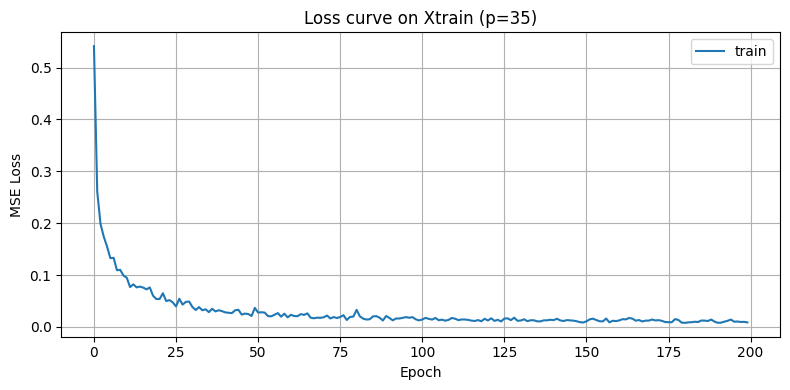

In [65]:
p = best_p

X_best, y_best = create_windows(train_data, p)
X_best = X_best.reshape((X_best.shape[0], X_best.shape[1], 1))

X_best_t = torch.tensor(X_best, dtype=torch.float32)
y_best_t = torch.tensor(y_best, dtype=torch.float32)

best_loader = DataLoader(TensorDataset(X_best_t, y_best_t), batch_size=32, shuffle=True)

torch.manual_seed(42)
best_model = CNN(p)
optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 200
train_losses = []

for epoch in range(n_epochs):
    best_model.train()
    batch_losses = []
    for xb, yb in best_loader:
        optimizer.zero_grad()
        loss = criterion(best_model(xb), yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{n_epochs}  train={train_losses[-1]:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"Loss curve on Xtrain (p={p})")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

all_data_scaled = (X - mu) / sigma

X_final, y_final = create_windows(all_data_scaled, p)
X_final = X_final.reshape((X_final.shape[0], X_final.shape[1], 1))

X_final_t = torch.tensor(X_final, dtype=torch.float32)
y_final_t = torch.tensor(y_final, dtype=torch.float32)

final_loader = DataLoader(TensorDataset(X_final_t, y_final_t), batch_size=32, shuffle=True)

torch.manual_seed(42)
final_model = CNN(p)
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3)

for epoch in range(n_epochs):
    final_model.train()
    for xb, yb in final_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()

# Predictions on validation set

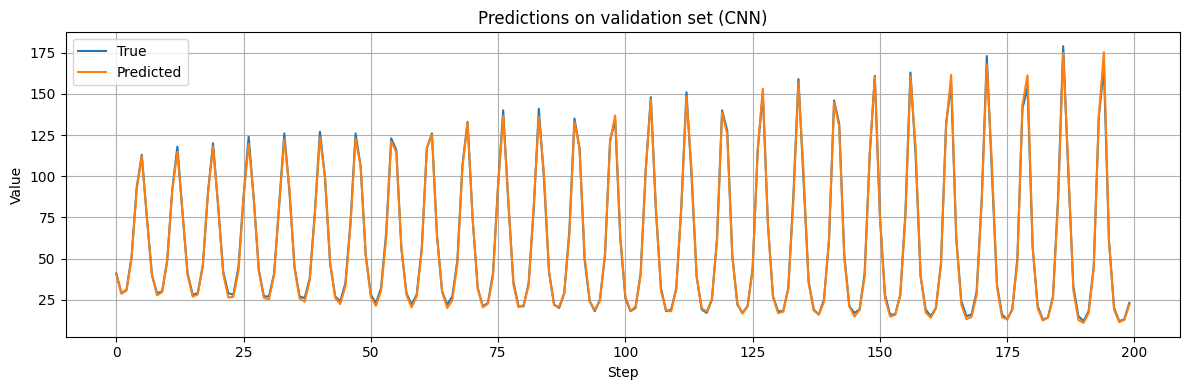

Validation MSE: 3.60


In [66]:
best_model.eval()
with torch.no_grad():
    val_with_context = np.concatenate([train_data[-p:], val_data])
    X_v, y_v = create_windows(val_with_context, p)
    X_v = X_v.reshape((X_v.shape[0], X_v.shape[1], 1))
    X_v_t = torch.tensor(X_v, dtype=torch.float32)
    y_pred_scaled = best_model(X_v_t).numpy().squeeze()

y_pred = y_pred_scaled * sigma + mu
y_true = y_v * sigma + mu

plt.figure(figsize=(12, 4))
plt.plot(y_true, label="True")
plt.plot(y_pred, label="Predicted")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("Predictions on validation set (CNN)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

mse = np.mean((y_pred - y_true) ** 2)
print(f"Validation MSE: {mse:.2f}")

# Recursive 200-step prediction

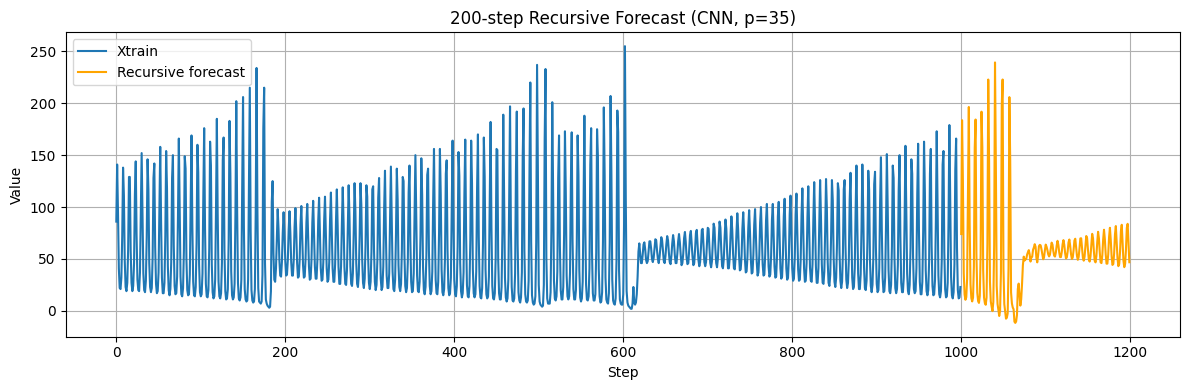

In [67]:
window = list(all_data_scaled[-p:])

final_model.eval()
recursive_preds_scaled = []

with torch.no_grad():
    for _ in range(200):
        x = torch.tensor(window[-p:], dtype=torch.float32).reshape(1, p, 1)
        next_val = final_model(x).item()
        recursive_preds_scaled.append(next_val)
        window.append(next_val)

# Convert back to original scale
recursive_preds = np.array(recursive_preds_scaled) * sigma + mu

plt.figure(figsize=(12, 4))
plt.plot(range(len(X)), X, label="Xtrain")
plt.plot(range(len(X), len(X) + 200), recursive_preds, label="Recursive forecast", color="orange")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title(f"200-step Recursive Forecast (CNN, p={p})")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()